In [22]:
# needed imports
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import mapclassify as mc

In [2]:
gdf = gpd.read_file("../../data/processed/king_tracts_analysis.geojson")

In [3]:
gdf.columns

Index(['geoid', 'asthma_prevalence', 'asthma_ci_lower', 'asthma_ci_upper',
       'population_total', 'population_adult', 'distance_tri_km',
       'tri_count_2km', 'tri_total_releases_2km', 'road_density_km_per_km2',
       'green_space_percent', 'area_km2', 'percent_low_income',
       'percent_minority', 'percent_less_than_hs', 'geometry'],
      dtype='str')

In [4]:
gdf.describe()

,asthma_prevalence,asthma_ci_lower,asthma_ci_upper,population_total,population_adult,distance_tri_km,tri_count_2km,tri_total_releases_2km,road_density_km_per_km2,green_space_percent,area_km2,percent_low_income,percent_minority,percent_less_than_hs
count,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,494.000000,493.000000,494.000000,494.000000
mean,9.840081,9.058907,10.647368,4594.483806,3670.991903,2.902475,3.087045,15734.423089,11.120861,0.162756,11.604354,5.790554,43.692569,2.109898
std,0.951700,0.877133,1.018024,1229.337615,923.057955,2.674676,7.696744,49286.906646,5.666995,0.158868,82.731847,8.131670,17.777440,2.712288
min,7.300000,6.700000,8.000000,1165.000000,1034.000000,0.000000,0.000000,0.000000,0.332506,0.000000,0.072977,0.000000,4.595518,0.000000
25%,9.300000,8.500000,10.025000,3742.750000,3028.250000,1.088616,0.000000,0.000000,7.385329,0.044081,1.286218,1.325019,28.811178,0.235594
50%,9.900000,9.100000,10.700000,4413.500000,3530.000000,2.418586,0.000000,0.000000,10.313160,0.110723,2.490315,3.583978,43.401444,1.073692
75%,10.500000,9.600000,11.300000,5411.000000,4363.750000,3.694444,2.000000,6437.466000,14.065112,0.240998,4.325316,7.534247,57.043695,3.038016
max,13.900000,12.700000,15.300000,8837.000000,7338.000000,22.060179,67.000000,331272.362000,31.871314,0.873741,1417.368479,100.000000,92.596201,18.781302


In [5]:
gdf.dtypes

geoid                           str
asthma_prevalence           float64
asthma_ci_lower             float64
asthma_ci_upper             float64
population_total              int32
population_adult              int32
distance_tri_km             float64
tri_count_2km                 int32
tri_total_releases_2km      float64
road_density_km_per_km2     float64
green_space_percent         float64
area_km2                    float64
percent_low_income          float64
percent_minority            float64
percent_less_than_hs        float64
geometry                   geometry
dtype: object

In [6]:
gdf.isna().sum()

geoid                      0
asthma_prevalence          0
asthma_ci_lower            0
asthma_ci_upper            0
population_total           0
population_adult           0
distance_tri_km            0
tri_count_2km              0
tri_total_releases_2km     0
road_density_km_per_km2    0
green_space_percent        0
area_km2                   0
percent_low_income         1
percent_minority           0
percent_less_than_hs       0
geometry                   0
dtype: int64

In [7]:
gdf[gdf["percent_low_income"].isna()]

,geoid,asthma_prevalence,asthma_ci_lower,asthma_ci_upper,population_total,population_adult,distance_tri_km,tri_count_2km,tri_total_releases_2km,road_density_km_per_km2,green_space_percent,area_km2,percent_low_income,percent_minority,percent_less_than_hs,geometry
1,53033005307,13.9,12.7,15.3,2921,2824,3.331304,0,0.0,16.087138,0.022185,0.129932,NaN,45.805593,0.0,"POLYGON ((551742.634 5279083.437, 551742.949 5..."


In [8]:
# it is only one value which represent less than 0.3% won't bias results
# i will use sample mean to fill null 
# other approch could be --> fill with k neighbords mean 

# Check the current mean
mean_low_income = gdf['percent_low_income'].mean()
print(f"Mean percent_low_income: {mean_low_income:.2f}%")

# Fill the missing value
gdf['percent_low_income'] = gdf['percent_low_income'].fillna(mean_low_income)

# Verify it's fixed
print(f"Missing values after imputation: {gdf['percent_low_income'].isna().sum()}")

# Document which tract was imputed
print(f"Imputed tract: {gdf[gdf['geoid'] == '53033005307']['percent_low_income'].values}")

Mean percent_low_income: 5.79%
Missing values after imputation: 0
Imputed tract: [5.79055384]


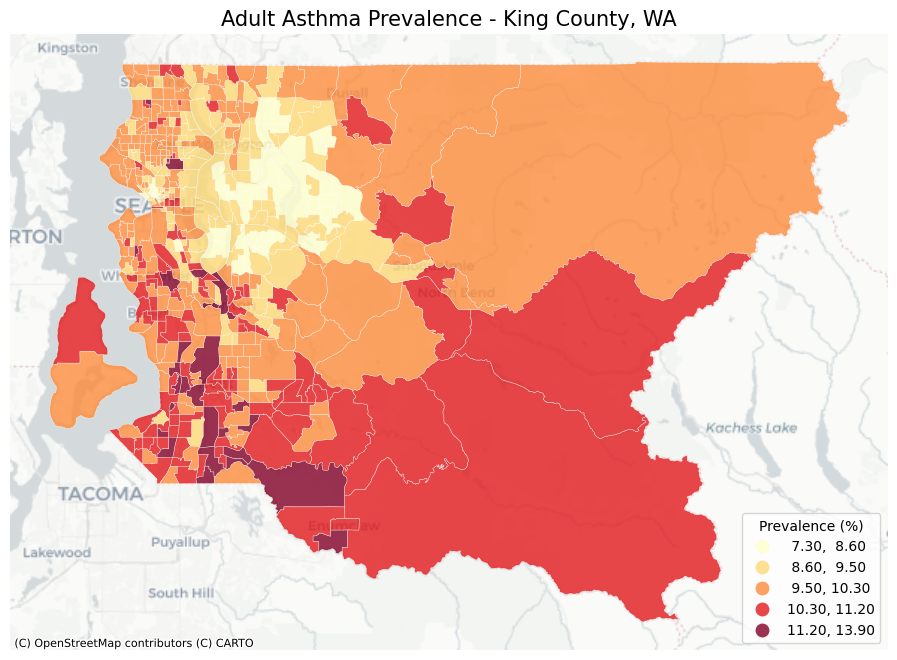

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

# Plotting with styling
gdf.to_crs(epsg=3857).plot(
    ax=ax,
    column="asthma_prevalence",
    scheme="NaturalBreaks", # could also use Quantiles
    k=5, 
    cmap="YlOrRd",
    legend=True,
    edgecolor='white',      
    linewidth=0.3,
    alpha=0.8,              # Transparency for the basemap
    legend_kwds={'title': "Prevalence (%)", 'loc': 'lower right'}
)

# Add a basemap for spatial context
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_title("Adult Asthma Prevalence - King County, WA", fontsize=15)
ax.set_axis_off()

plt.show()

<Axes: >

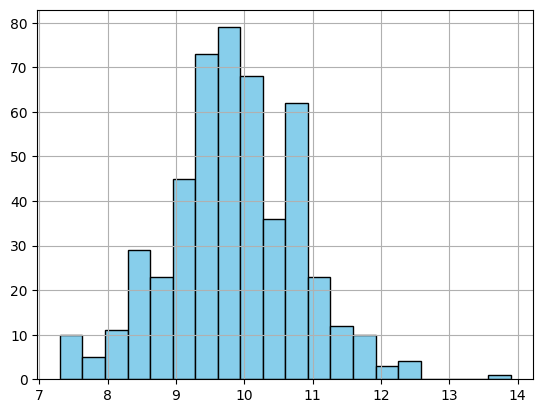

In [10]:
gdf['asthma_prevalence'].hist(bins=20, color='skyblue', edgecolor='black')

#### Asthma Distribution Observations

##### 1. Choropleth Pattern & Visual Dominance
The choropleth map suggests that **mid-to-high prevalence ranges (≈ 8.6%–11.2%)** cover large portions of the southern and eastern areas of King County.

- **What the map implies**: Many adjacent tracts share similar prevalence levels, which *may* indicate **positive spatial autocorrelation** (nearby areas having similar values).
- **How to verify (not just eyeballing)**: Use **Global Moran’s I** to test whether the observed clustering is greater than expected under spatial randomness:

$$
I = \frac{n}{W}\;
\frac{\sum_{i=1}^{n}\sum_{j=1}^{n} w_{ij}(x_i-\bar{x})(x_j-\bar{x})}
{\sum_{i=1}^{n}(x_i-\bar{x})^2}
$$

##### 2. Low-Prevalence Core & Plausible Explanations
The central urban core appears in the lowest prevalence class (≈ 7.3%–8.6%).

- **Working hypothesis (to be tested)**: This pattern could be consistent with **social determinants of health** and environmental exposure differences. For example, the core may coincide with:
  - higher socioeconomic status (SES) and better health access,
  - different exposure profiles (pollution sources, commuting patterns).

##### 3. Histogram Insight & Map-Perception Bias
To complement the map, we examine the distribution of `asthma_prevalence` using a histogram.

- **Distribution insight**: Most tracts cluster around **~9.5%–10%**, while very high values (e.g., **>12%**) are relatively rare.
- **Why the map can look “mostly red”**: Choropleths are influenced by **polygon size**. Large rural tracts occupy more visual space and can dominate the viewer’s perception even if they represent a smaller share of tracts (or population). The histogram helps confirm whether “high prevalence” is common across tracts or visually amplified by geography and class breaks.
- **Note on MAUP (important but different)**: A histogram does **not** “solve” the **Modifiable Areal Unit Problem (MAUP)**. MAUP refers to how results can change if the same phenomenon is aggregated to different spatial units or scales (e.g., tracts vs ZIP codes vs a grid). A proper MAUP check would repeat the analysis under alternative zoning/scale choices and compare whether the conclusions remain stable.


In [35]:
# What percentage of tracts are in each bin?
import numpy as np
import pandas as pd

bins = [7.3, 8.6, 9.5, 10.3, 11.2, 13.9]
labels = ['7.3-8.6', '8.6-9.5', '9.5-10.3', '10.3-11.2', '11.2-13.9']

gdf['asthma_bin'] = pd.cut(gdf['asthma_prevalence'], bins=bins, labels=labels)
print(gdf['asthma_bin'].value_counts().sort_index())
print(f"\nPercentage in highest bin (11.2-13.9%): {(gdf['asthma_prevalence'] > 11.2).sum() / len(gdf) * 100:.1f}%")

asthma_bin
7.3-8.6       54
8.6-9.5      118
9.5-10.3     185
10.3-11.2    106
11.2-13.9     30
Name: count, dtype: int64

Percentage in highest bin (11.2-13.9%): 6.1%


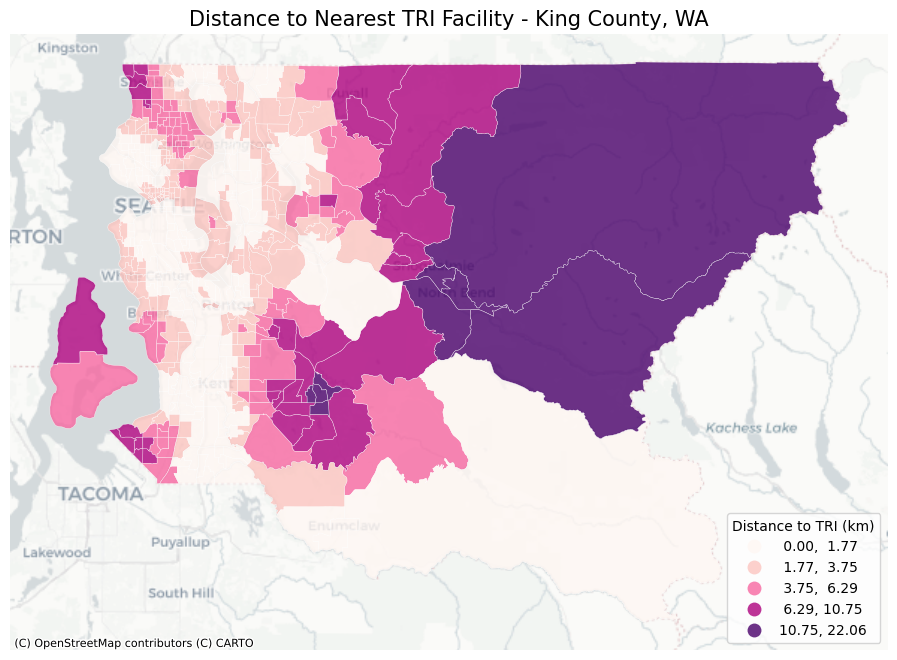

In [38]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

gdf.to_crs(epsg=3857).plot(
    ax=ax,
    column="distance_tri_km",
    scheme="NaturalBreaks",
    k=5, 
    cmap="RdPu",
    legend=True,
    edgecolor='white',      
    linewidth=0.3,
    alpha=0.8,
    legend_kwds={'title': "Distance to TRI (km)", 'loc': 'lower right'}  # Fixed!
)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_title("Distance to Nearest TRI Facility - King County, WA", fontsize=15)  # More descriptive
ax.set_axis_off()

plt.show()

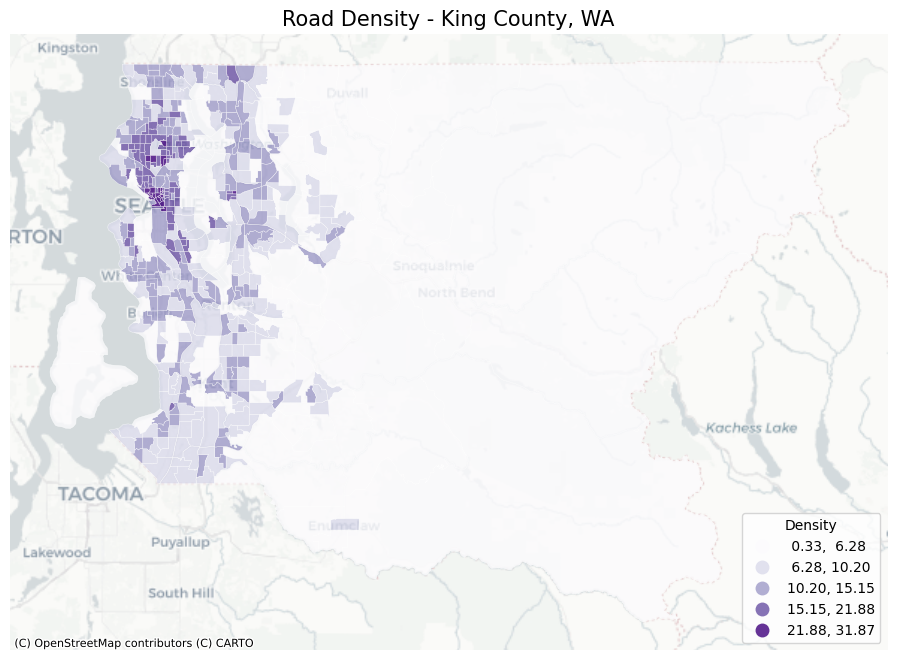

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

gdf.to_crs(epsg=3857).plot(
    ax=ax,
    column="road_density_km_per_km2",
    scheme="NaturalBreaks",
    k=5, 
    cmap="Purples",
    legend=True,
    edgecolor='white',      
    linewidth=0.3,
    alpha=0.8,
    legend_kwds={'title': "Density", 'loc': 'lower right'}  
)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_title("Road Density - King County, WA", fontsize=15)  # More descriptive
ax.set_axis_off()

plt.show()

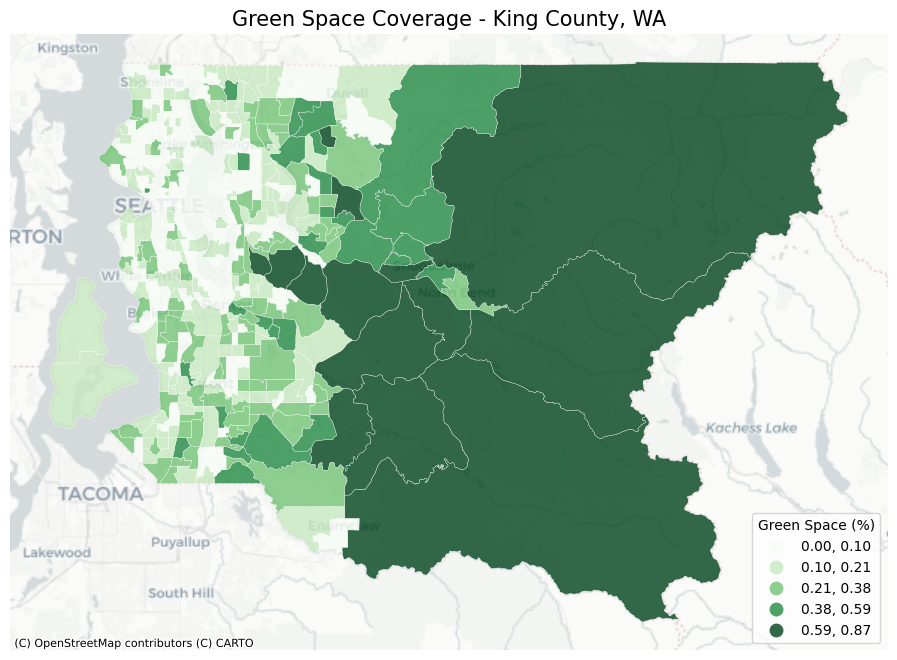

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

gdf.to_crs(epsg=3857).plot(
    ax=ax,
    column="green_space_percent",
    scheme="NaturalBreaks",
    k=5, 
    cmap="Greens",
    legend=True,
    edgecolor='white',      
    linewidth=0.3,
    alpha=0.8,
    legend_kwds={'title': "Green Space (%)", 'loc': 'lower right'}  
)

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)
ax.set_title("Green Space Coverage - King County, WA", fontsize=15)  # More descriptive
ax.set_axis_off()

plt.show()

✓ Comparison figure saved!


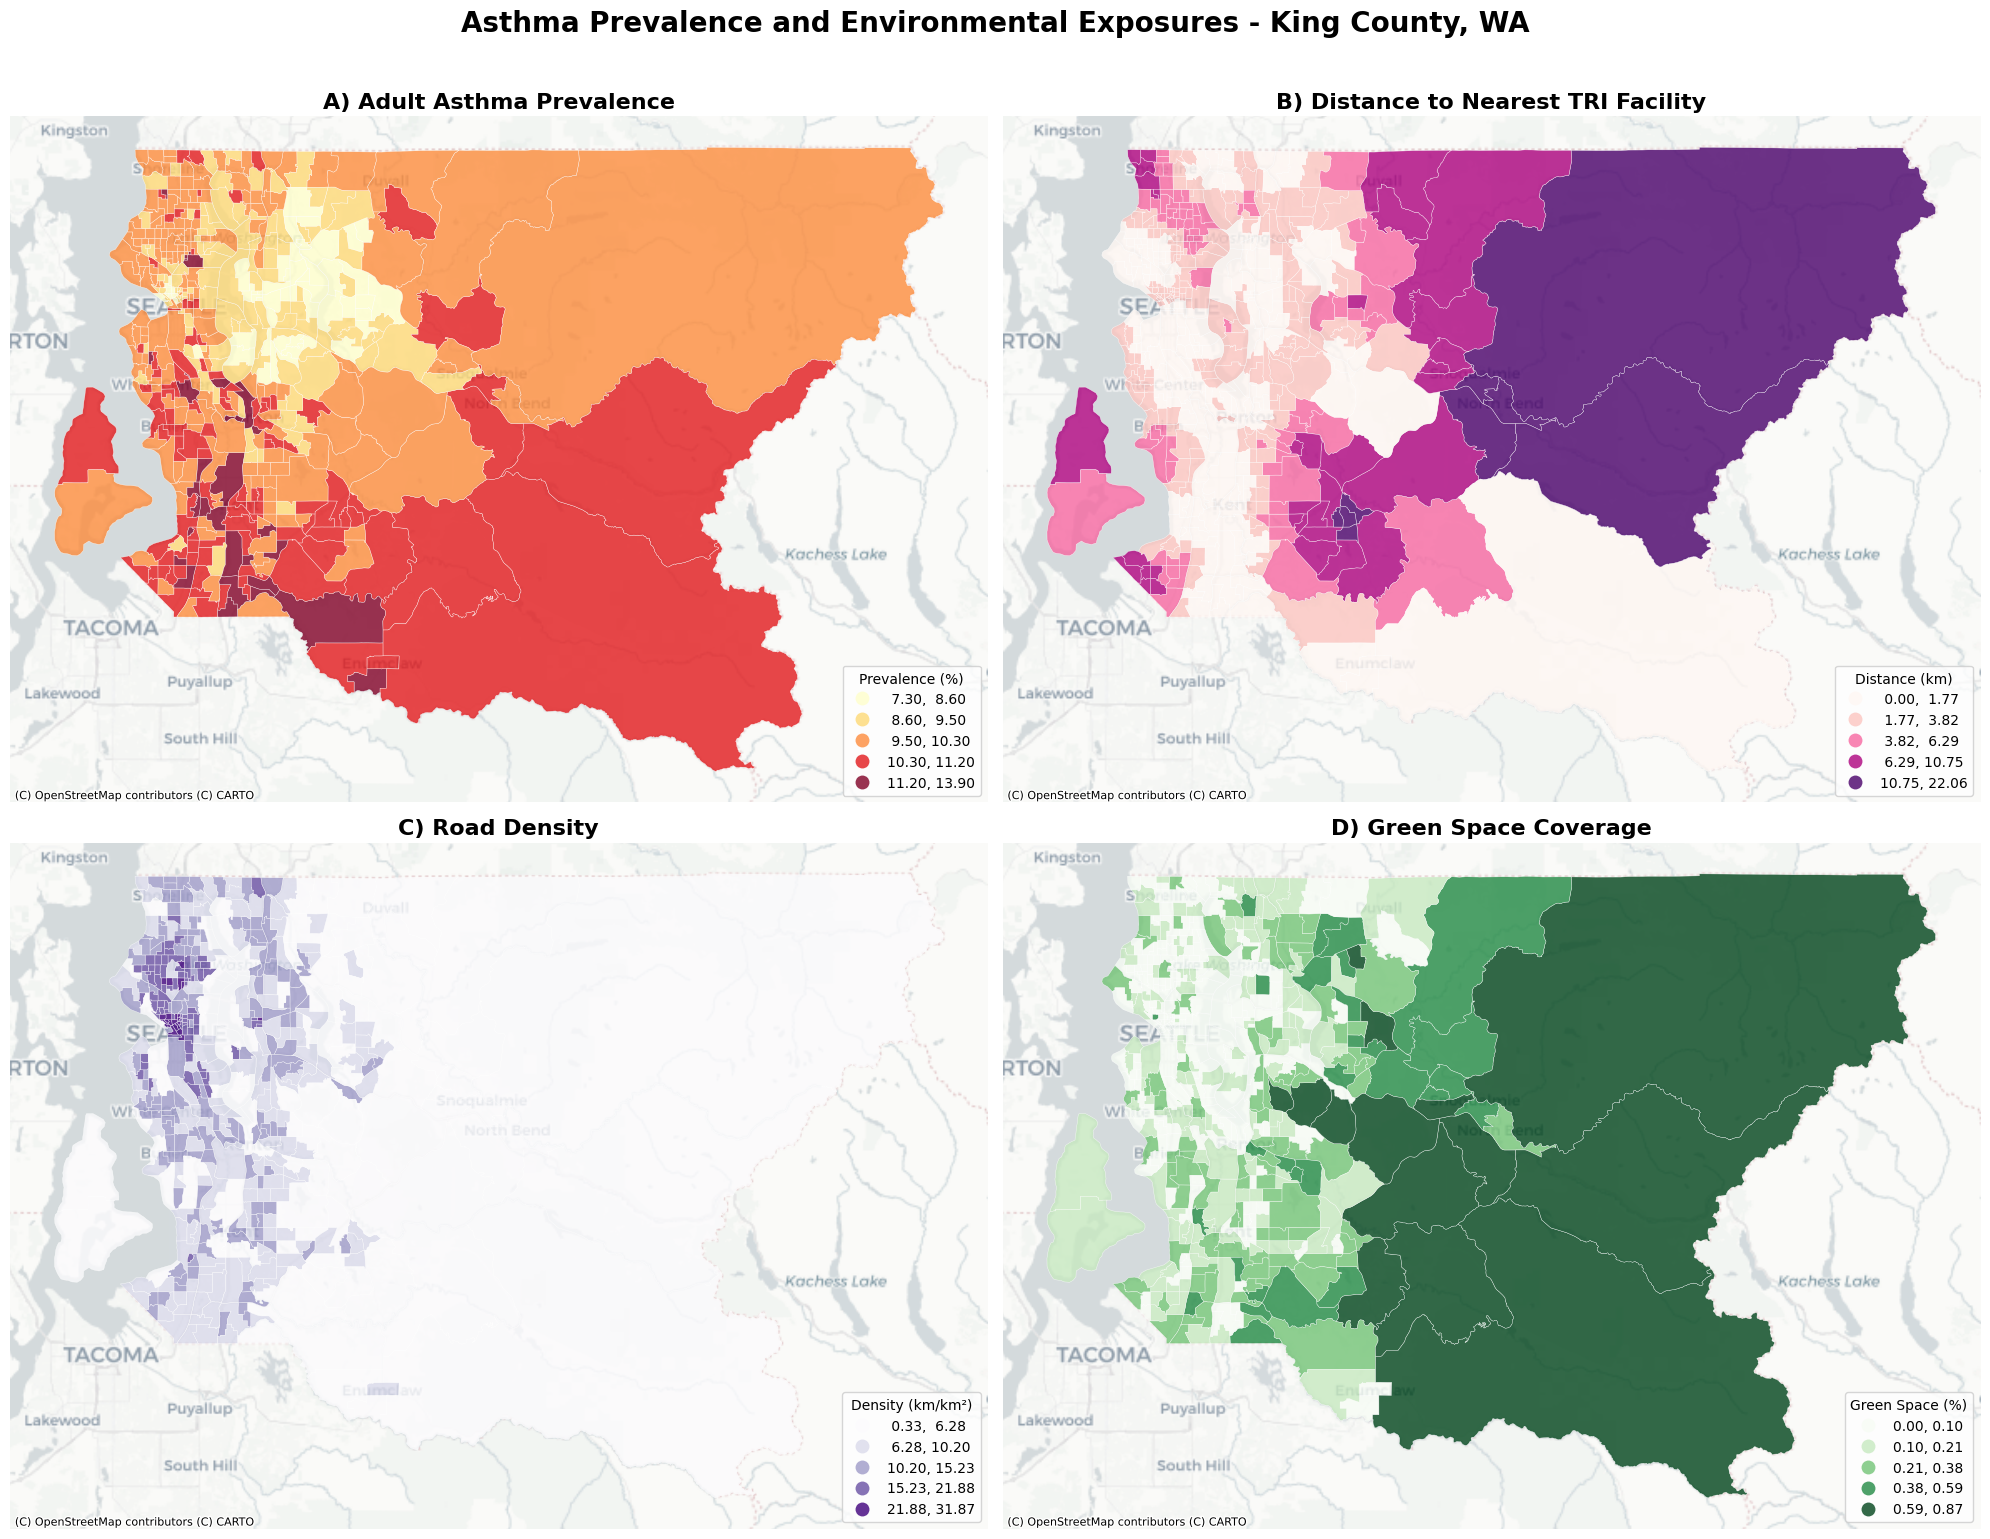

In [44]:
# Create 2x2 subplot figure
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
axes = axes.flatten()  # Flatten to make indexing easier

# Convert to web mercator for basemap
gdf_web = gdf.to_crs(epsg=3857)

# Map 1: Asthma Prevalence
gdf_web.plot(
    ax=axes[0],
    column="asthma_prevalence",
    scheme="NaturalBreaks",
    k=5,
    cmap="YlOrRd",
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    alpha=0.8,
    legend_kwds={'title': "Prevalence (%)", 'loc': 'lower right', 'fontsize': 10}
)
cx.add_basemap(axes[0], source=cx.providers.CartoDB.Positron)
axes[0].set_title("A) Adult Asthma Prevalence", fontsize=16, fontweight='bold')
axes[0].set_axis_off()

# Map 2: TRI Distance
gdf_web.plot(
    ax=axes[1],
    column="distance_tri_km",
    scheme="NaturalBreaks",
    k=5,
    cmap="RdPu",
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    alpha=0.8,
    legend_kwds={'title': "Distance (km)", 'loc': 'lower right', 'fontsize': 10}
)
cx.add_basemap(axes[1], source=cx.providers.CartoDB.Positron)
axes[1].set_title("B) Distance to Nearest TRI Facility", fontsize=16, fontweight='bold')
axes[1].set_axis_off()

# Map 3: Road Density
gdf_web.plot(
    ax=axes[2],
    column="road_density_km_per_km2",
    scheme="NaturalBreaks",
    k=5,
    cmap="Purples",
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    alpha=0.8,
    legend_kwds={'title': "Density (km/km²)", 'loc': 'lower right', 'fontsize': 10}
)
cx.add_basemap(axes[2], source=cx.providers.CartoDB.Positron)
axes[2].set_title("C) Road Density", fontsize=16, fontweight='bold')
axes[2].set_axis_off()

# Map 4: Green Space
gdf_web.plot(
    ax=axes[3],
    column="green_space_percent",
    scheme="NaturalBreaks",
    k=5,
    cmap="Greens",
    legend=True,
    edgecolor='white',
    linewidth=0.3,
    alpha=0.8,
    legend_kwds={'title': "Green Space (%)", 'loc': 'lower right', 'fontsize': 10}
)
cx.add_basemap(axes[3], source=cx.providers.CartoDB.Positron)
axes[3].set_title("D) Green Space Coverage", fontsize=16, fontweight='bold')
axes[3].set_axis_off()

# Overall title
fig.suptitle('Asthma Prevalence and Environmental Exposures - King County, WA', 
             fontsize=20, fontweight='bold', y=0.98)

# Adjust layout
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Save figure
plt.savefig('Four_Map_Comparison.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ Comparison figure saved!")

plt.show()

In [46]:
from libpysal.weights import Queen

# Create Queen contiguity weights
w = Queen.from_dataframe(gdf)

# QA Check - examine neighbor structure
print(f"Total tracts: {gdf.shape[0]}")
print(f"Average neighbors per tract: {w.mean_neighbors:.2f}")
print(f"Min neighbors: {w.min_neighbors}")
print(f"Max neighbors: {w.max_neighbors}")
print(f"Any islands (0 neighbors)? {w.islands}")

# Row-standardize weights (required for Moran's I)
w.transform = 'r'

C:\Users\yazed\AppData\Local\Temp\ipykernel_20504\1307170143.py:4: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)


Total tracts: 494
Average neighbors per tract: 6.07
Min neighbors: 1
Max neighbors: 12
Any islands (0 neighbors)? []


In [47]:
from esda.moran import Moran

# Calculate Moran's I for asthma prevalence
moran = Moran(gdf['asthma_prevalence'], w)

# Display results
print("=" * 50)
print("GLOBAL MORAN'S I RESULTS")
print("=" * 50)
print(f"Moran's I statistic: {moran.I:.4f}")
print(f"Expected I (random): {moran.EI:.4f}")
print(f"p-value: {moran.p_sim:.4f}")
print(f"z-score: {moran.z_sim:.4f}")
print("=" * 50)

# Interpretation
if moran.p_sim < 0.05:
    if moran.I > 0:
        print("SIGNIFICANT POSITIVE spatial autocorrelation")
        print("Asthma is CLUSTERED (similar values near each other)")
    else:
        print("SIGNIFICANT NEGATIVE spatial autocorrelation")
        print("Asthma shows DISPERSION (dissimilar values near each other)")
else:
    print("NO significant spatial autocorrelation")
    print("Asthma appears randomly distributed")

GLOBAL MORAN'S I RESULTS
Moran's I statistic: 0.6083
Expected I (random): -0.0020
p-value: 0.0010
z-score: 23.5998
SIGNIFICANT POSITIVE spatial autocorrelation
Asthma is CLUSTERED (similar values near each other)


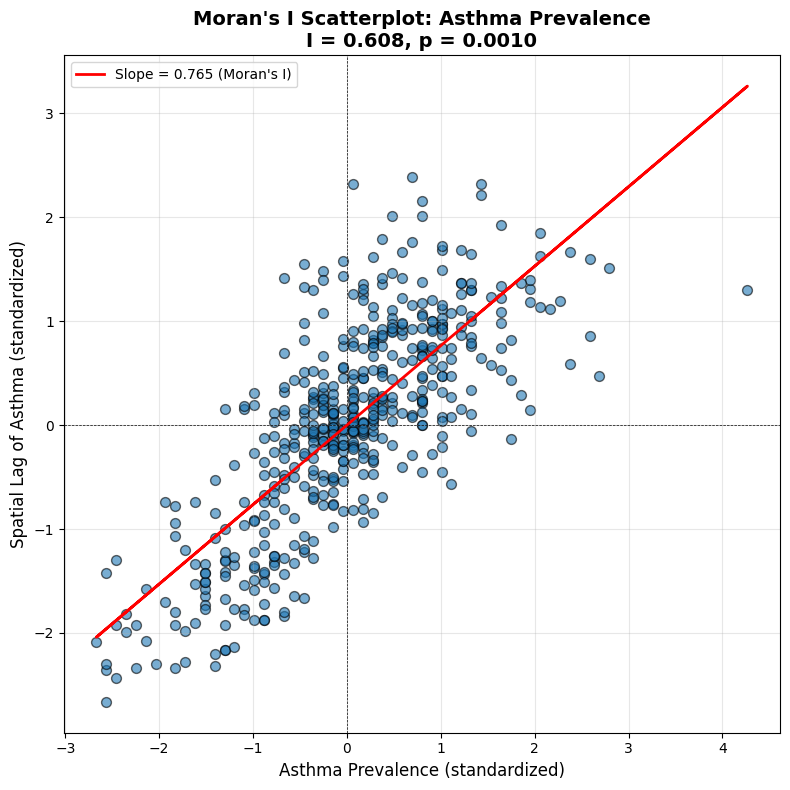

In [49]:
# Get standardized values
y = gdf['asthma_prevalence']
y_std = (y - y.mean()) / y.std()

# Calculate spatial lag (average of neighbors)
y_lag = w.sparse.dot(y)
y_lag_std = (y_lag - y_lag.mean()) / y_lag.std()

# Create scatterplot
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(y_std, y_lag_std, alpha=0.6, edgecolors='black', s=50)

# Add quadrant lines
ax.axhline(0, color='black', linestyle='--', linewidth=0.5)
ax.axvline(0, color='black', linestyle='--', linewidth=0.5)

# Add regression line
m, b = np.polyfit(y_std, y_lag_std, 1)
ax.plot(y_std, m*y_std + b, 'r-', linewidth=2, label=f'Slope = {m:.3f} (Moran\'s I)')

ax.set_xlabel('Asthma Prevalence (standardized)', fontsize=12)
ax.set_ylabel('Spatial Lag of Asthma (standardized)', fontsize=12)
ax.set_title(f"Moran's I Scatterplot: Asthma Prevalence\nI = {moran.I:.3f}, p = {moran.p_sim:.4f}", 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Morans_I_Scatterplot_Simple.png', dpi=300, bbox_inches='tight')
plt.show()

In [50]:
from esda.moran import Moran_Local

# Calculate Local Moran's I
lisa = Moran_Local(gdf['asthma_prevalence'], w)

# Add LISA results to your dataframe
gdf['lisa_cluster'] = lisa.q  # Quadrant classification
gdf['lisa_pvalue'] = lisa.p_sim  # Statistical significance
gdf['lisa_significant'] = lisa.p_sim < 0.05  # Significant at 5% level

# Summary statistics
print("=" * 50)
print("LISA CLUSTER SUMMARY")
print("=" * 50)
print(f"Total tracts: {len(gdf)}")
print(f"Significant clusters: {gdf['lisa_significant'].sum()} ({gdf['lisa_significant'].sum()/len(gdf)*100:.1f}%)")
print("\nCluster type breakdown (significant only):")
print(gdf[gdf['lisa_significant']]['lisa_cluster'].value_counts().sort_index())
print("\nCluster type labels:")
print("  1 = High-High (hotspots)")
print("  2 = Low-High (outliers)")
print("  3 = Low-Low (coldspots)")
print("  4 = High-Low (outliers)")
print("=" * 50)

LISA CLUSTER SUMMARY
Total tracts: 494
Significant clusters: 191 (38.7%)

Cluster type breakdown (significant only):
lisa_cluster
1    83
2    11
3    95
4     2
Name: count, dtype: int64

Cluster type labels:
  1 = High-High (hotspots)
  2 = Low-High (outliers)
  3 = Low-Low (coldspots)
  4 = High-Low (outliers)


In [51]:
# Create meaningful labels for clusters
def classify_cluster(row):
    if not row['lisa_significant']:
        return 'Not Significant'
    elif row['lisa_cluster'] == 1:
        return 'High-High (Hotspot)'
    elif row['lisa_cluster'] == 2:
        return 'Low-High (Outlier)'
    elif row['lisa_cluster'] == 3:
        return 'Low-Low (Coldspot)'
    elif row['lisa_cluster'] == 4:
        return 'High-Low (Outlier)'
    else:
        return 'Not Significant'

gdf['cluster_type'] = gdf.apply(classify_cluster, axis=1)

# Count by type
print("\nFinal cluster classification:")
print(gdf['cluster_type'].value_counts())


Final cluster classification:
cluster_type
Not Significant        303
Low-Low (Coldspot)      95
High-High (Hotspot)     83
Low-High (Outlier)      11
High-Low (Outlier)       2
Name: count, dtype: int64


C:\Users\yazed\AppData\Local\Temp\ipykernel_20504\4093688619.py:47: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  legend = ax.legend(
C:\Users\yazed\AppData\Local\Temp\ipykernel_20504\4093688619.py:47: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend(


✓ Clear LISA map saved!


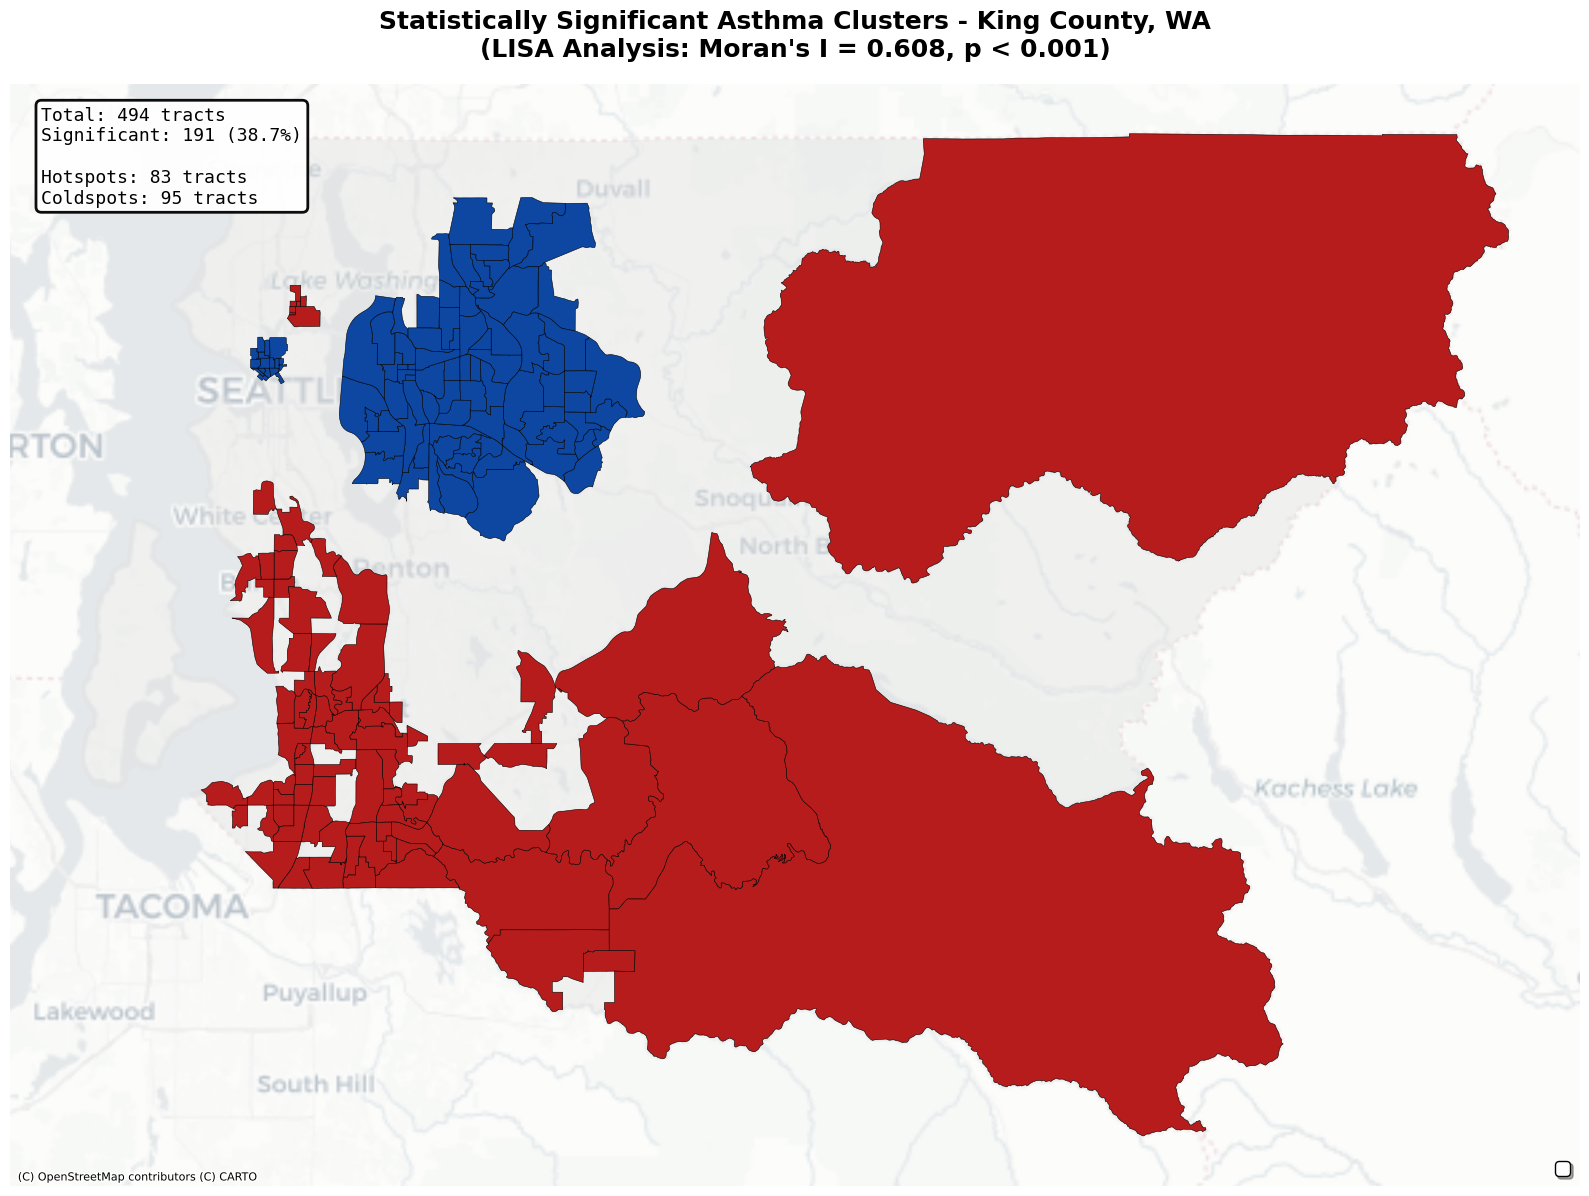

In [54]:
import matplotlib.pyplot as plt
import contextily as cx

# Simplify to 3 categories only
gdf['cluster_simple'] = 'Not Significant'
gdf.loc[gdf['cluster_type'] == 'High-High (Hotspot)', 'cluster_simple'] = 'Asthma Hotspot'
gdf.loc[gdf['cluster_type'] == 'Low-Low (Coldspot)', 'cluster_simple'] = 'Asthma Coldspot'
# Combine outliers with not significant (they're rare anyway)

# High-contrast colors
colors = {
    'Asthma Hotspot': '#B71C1C',      # Dark red (strong)
    'Asthma Coldspot': '#0D47A1',     # Dark blue (strong)
    'Not Significant': '#E0E0E0'      # Light gray
}

# Create figure
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
gdf_web = gdf.to_crs(epsg=3857)

# Plot in order (background first)
for category in ['Not Significant', 'Asthma Coldspot', 'Asthma Hotspot']:
    subset = gdf_web[gdf_web['cluster_simple'] == category]
    if len(subset) > 0:
        alpha = 0.4 if category == 'Not Significant' else 1.0
        edgecolor = 'white' if category == 'Not Significant' else 'black'
        linewidth = 0.05 if category == 'Not Significant' else 0.4
        
        subset.plot(
            ax=ax,
            color=colors[category],
            edgecolor=edgecolor,
            linewidth=linewidth,
            alpha=alpha,
            label=f'{category} (n={len(subset)})'
        )

# Add basemap
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron, alpha=0.6)

# Title
ax.set_title("Statistically Significant Asthma Clusters - King County, WA\n(LISA Analysis: Moran's I = 0.608, p < 0.001)", 
             fontsize=18, fontweight='bold', pad=20)
ax.set_axis_off()

# Legend with better positioning and styling
legend = ax.legend(
    loc='lower right', 
    fontsize=14, 
    framealpha=1.0, 
    edgecolor='black',
    fancybox=True,
    shadow=True
)

# Add summary box
textstr = f'Total: {len(gdf)} tracts\nSignificant: 191 (38.7%)\n\nHotspots: 83 tracts\nColdspots: 95 tracts'
props = dict(boxstyle='round', facecolor='white', alpha=0.95, edgecolor='black', linewidth=2)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=13, 
        verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
plt.savefig('LISA_Final_Map.png', dpi=300, bbox_inches='tight', facecolor='white')
print("✓ Clear LISA map saved!")
plt.show()

In [55]:
import statsmodels.api as sm
import pandas as pd

# Step 1: Select your variables
outcome = 'asthma_prevalence'

predictors = [
    # Socioeconomic controls (confounders)
    'percent_low_income',
    'percent_minority', 
    'percent_less_than_hs',
    
    # Environmental exposures (what we care about)
    'distance_tri_km',
    'road_density_km_per_km2',
    'green_space_percent'
]

# Step 2: Prepare the data
# Drop any rows with missing values
model_data = gdf[['geoid', outcome] + predictors].dropna()

print(f"Sample size: {len(model_data)} tracts (out of {len(gdf)})")

# Step 3: Set up X (predictors) and y (outcome)
X = model_data[predictors]
y = model_data[outcome]

# Add constant (intercept)
X = sm.add_constant(X)

# Step 4: Run OLS regression
model = sm.OLS(y, X).fit()

# Step 5: Print results
print("\n" + "="*70)
print("OLS REGRESSION RESULTS")
print("="*70)
print(model.summary())

Sample size: 494 tracts (out of 494)

OLS REGRESSION RESULTS
                            OLS Regression Results                            
Dep. Variable:      asthma_prevalence   R-squared:                       0.279
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     31.46
Date:                Mon, 09 Feb 2026   Prob (F-statistic):           5.42e-32
Time:                        13:15:15   Log-Likelihood:                -595.08
No. Observations:                 494   AIC:                             1204.
Df Residuals:                     487   BIC:                             1234.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------

In [56]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\n" + "="*50)
print("VIF (Variance Inflation Factor)")
print("="*50)
print(vif_data)
print("\nInterpretation:")
print("  VIF < 5   = No problem")
print("  VIF 5-10  = Moderate multicollinearity")
print("  VIF > 10  = Serious problem")
print("="*50)


VIF (Variance Inflation Factor)
                  Variable        VIF
0                    const  19.973402
1       percent_low_income   1.200740
2         percent_minority   1.695080
3     percent_less_than_hs   1.512020
4          distance_tri_km   1.222228
5  road_density_km_per_km2   1.508738
6      green_space_percent   1.546930

Interpretation:
  VIF < 5   = No problem
  VIF 5-10  = Moderate multicollinearity
  VIF > 10  = Serious problem


In [57]:
from esda.moran import Moran

# Get residuals from your OLS model
residuals = model.resid

# Calculate Moran's I on residuals (using same weights from Phase E)
moran_resid = Moran(residuals, w)

print("\n" + "="*50)
print("RESIDUAL SPATIAL AUTOCORRELATION TEST")
print("="*50)
print(f"Moran's I (residuals): {moran_resid.I:.4f}")
print(f"p-value: {moran_resid.p_sim:.4f}")
print(f"z-score: {moran_resid.z_sim:.4f}")
print("\nInterpretation:")
if moran_resid.p_sim < 0.05:
    print("SIGNIFICANT spatial autocorrelation in residuals")
    print("OLS is biased - need spatial regression model")
else:
    print("No significant spatial autocorrelation")
    print("OLS is fine - can trust the results")
print("="*50)


RESIDUAL SPATIAL AUTOCORRELATION TEST
Moran's I (residuals): 0.4765
p-value: 0.0010
z-score: 18.2031

Interpretation:
SIGNIFICANT spatial autocorrelation in residuals
OLS is biased - need spatial regression model


In [58]:
from spreg import GM_Error

# Prepare data (same as OLS)
y_array = y.values.reshape(-1, 1)
X_array = X.values

# Run Spatial Error Model
spatial_error = GM_Error(
    y_array, 
    X_array,
    w=w,
    name_y=outcome,
    name_x=X.columns.tolist(),
    name_w="Queen",
    name_ds="King County Asthma"
)

# Print results
print("\n" + "="*70)
print("SPATIAL ERROR MODEL RESULTS")
print("="*70)
print(spatial_error.summary)


SPATIAL ERROR MODEL RESULTS
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: GM SPATIALLY WEIGHTED LEAST SQUARES
------------------------------------------------------
Data set            :King County Asthma
Weights matrix      :       Queen
Dependent Variable  :asthma_prevalence                Number of Observations:         494
Mean dependent var  :      9.8401                Number of Variables   :           7
S.D. dependent var  :      0.9517                Degrees of Freedom    :         487
Pseudo R-squared    :      0.2536

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT        10.04617         0.17978        55.88152         0.00000
  percent_low_income         0.02951         0.00388         7.61135         0.00000
    percent_minority        